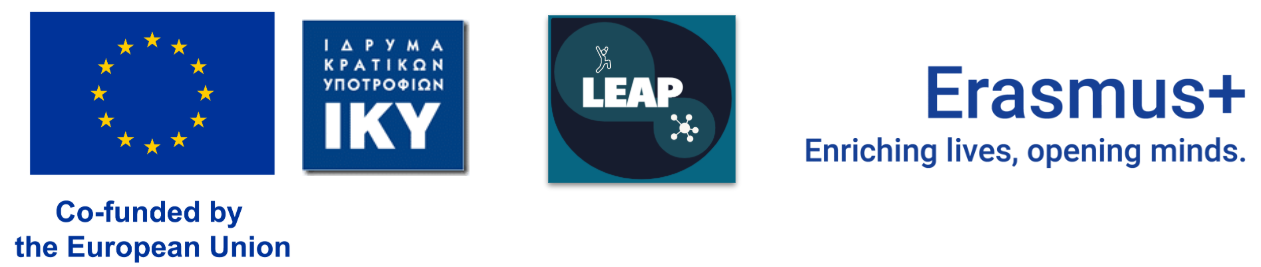

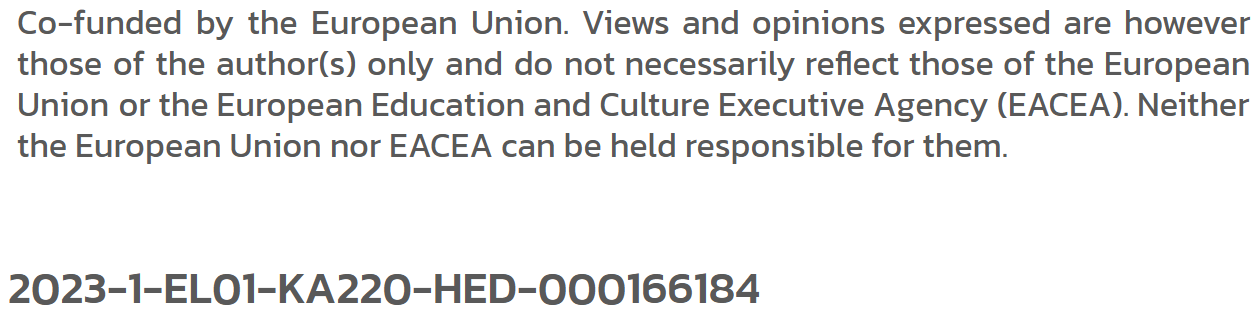

# Final Project, Option 3: How much structure can we find without the labels?

An agricultural co-op receives unlabelled deliveries of mixed wheat grain and wants to know how many distinct varieties are present, and how cleanly they separate, before committing to any sorting process. In this project I try to recover that structure using clustering alone.

In this pipeline I take a data set with a known grouping, hide that grouping and see how much of it I can recover using clustering alone. The labels are kept aside until the very end, where they serve only as an answer key.

**Central question:** how much of the real class structure can I recover without ever using the labels?

The data set is Seeds: 210 wheat kernels described by seven geometric measurements such as area, perimeter, and kernel length. The variety labels are set aside for the final check.

I carry out the following process: I scale the features, reduce them with PCA, cluster with K-Means, choose the number of clusters using the elbow and silhouette methods and validate the result against the known varieties with purity score and cross-tabulation.

## Part A. Setup and data



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Loading the data



In [2]:
feature_names = ["area", "perimeter", "compactness", "kernel_length",
                 "kernel_width", "asymmetry", "groove_length"]

seeds = fetch_openml(name="seeds", version=1, as_frame=True)

X = seeds.data.copy()
X.columns = feature_names

y_true = seeds.target.to_numpy().astype(int)

print("Rows and features:", X.shape)
X.head()

Rows and features: (210, 7)


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


### Scaling the features



In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature matrix:", X_scaled.shape)

Scaled feature matrix: (210, 7)


## Part B. Explore, without labels



(210, 2)
[0.71874303 0.17108184]
0.8898248618491232


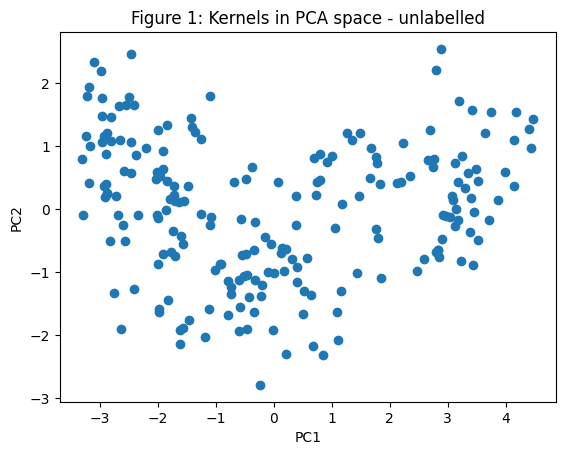

In [4]:
pca2 = PCA(n_components=2, random_state=42)
X2 = pca2.fit_transform(X_scaled)
print(X2.shape)
print(pca2.explained_variance_ratio_)
print(pca2.explained_variance_ratio_.sum())

plt.scatter(X2[:, 0], X2[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Figure 1: Kernels in PCA space - unlabelled")
plt.savefig("pca_unlabelled.png", dpi=150, bbox_inches="tight")
plt.show()

### What do we see?

The scatter plot reveals a continuous, elongated structure rather than completely distinct, isolated clusters. While we can spot about three regions of higher density (on the left, middle, and right), they merge and overlap without clear gaps. This lack of sharp separation could be because some seeds share intermediate characteristics, or because the 2D PCA projection captures approximately 89% of the variance, leaving out finer details that might separate the groups more clearly in the full 7-dimensional space.

## Part C. Clustering and selection of the number of groups



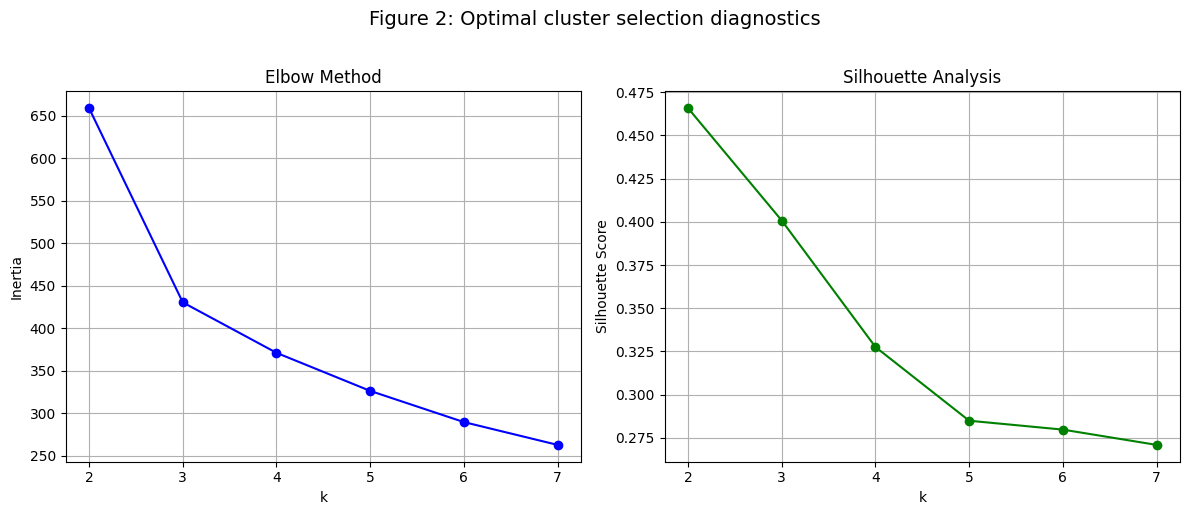

In [5]:
ks = range(2, 8)
inertias = []
sils = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(list(ks), inertias, marker="o", color="b")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")
ax1.set_xticks(list(ks))
ax1.grid(True)

ax2.plot(list(ks), sils, marker="o", color="g")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Analysis")
ax2.set_xticks(list(ks))
ax2.grid(True)

plt.suptitle("Figure 2: Optimal cluster selection diagnostics", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("clustering_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

### How many clusters?

Although the Silhouette score peaks at k=2 (0.47), the Elbow method reveals a distinct bend (elbow) at k=3, where the inertia drops sharply from k=2 to k=3 and then decreases at a much slower rate. Choosing k=3 provides the optimal balance: it significantly reduces within-cluster variance (inertia) while maintaining a solid silhouette score (~0.40). This choice of three clusters also aligns perfectly with the three density regions observed in our initial PCA scatter plot.

### K-Means



[2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 2 0 2 2 2 2 2 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 2 1 1 2 1 2 2 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 0 2 0 0 0 0 0 0 0 0]


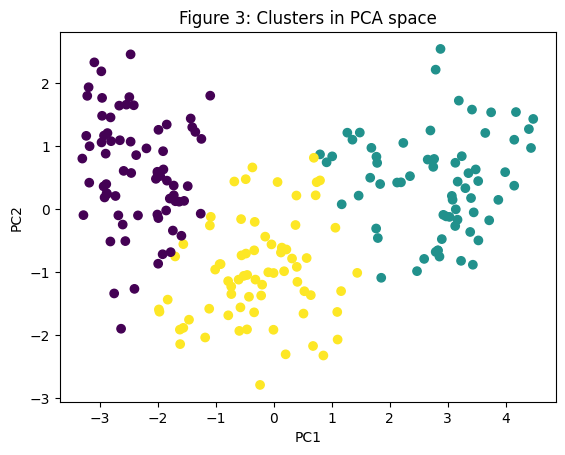

In [6]:
km = KMeans(n_clusters=3, n_init=10, random_state=42)
labels = km.fit_predict(X_scaled)
print(labels)

plt.scatter(X2[:, 0], X2[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Figure 3: Clusters in PCA space")
plt.savefig("kmeans_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

### Observations on the above diagram

This scatter plot visualizes the three clusters in a 2D space that results from the PCA. It is visible that there is some overlap between the clusters, especially between Cluster 0 (left) and Cluster 2 (middle). This highlights that some seeds have intermediate characteristics and that a perfect mathematical separation is difficult. I assume that because of these seeds, the model will have some incorrect predictions.

## Part D. Judge against the labels



In [7]:
print("Varieties present:", np.unique(y_true))
ct=pd.crosstab(labels, y_true)
print(ct)


Varieties present: [1 2 3]
col_0   1   2   3
row_0            
0       6   0  66
1       2  65   0
2      62   5   4


### Measuring the agreement



In [8]:
purity = ct.max(axis=1).sum() / ct.values.sum()
print("Purity score:", purity)

Purity score: 0.919047619047619


### Interpretation of the Purity Score and Cross-Tabulation

Our K-Means clustering achieved a very high **purity score of approximately 91.9%**, meaning that nearly 92% of all wheat kernels were grouped into clusters that align with their true varieties.

By looking at the cross-tabulation table, we can see exactly where the clustering succeeded and where the minor errors occurred:
* **Cluster 1 (Variety 2):** Relatively clean separation. It captures 65 out of 70 kernels of Variety 2, with only 2 misclassified kernels of Variety 1.
* **Cluster 0 (Variety 3):** Good enough. It captures 66 out of 70 kernels of Variety 3, with only 6 misclassified kernels of Variety 1.
* **Cluster 2 (Variety 1):** This is where most of the overlap resides. It contains 62 kernels of Variety 1, but also pulled in 5 kernels of Variety 2 and 4 kernels of Variety 3.

Overall, the high purity score confirms that the unsupervised clustering recovered the true biological varieties with very good accuracy, with the only notable confusion being intermediate kernels from Variety 1 overlapping into the other two clusters.

### Back to the picture



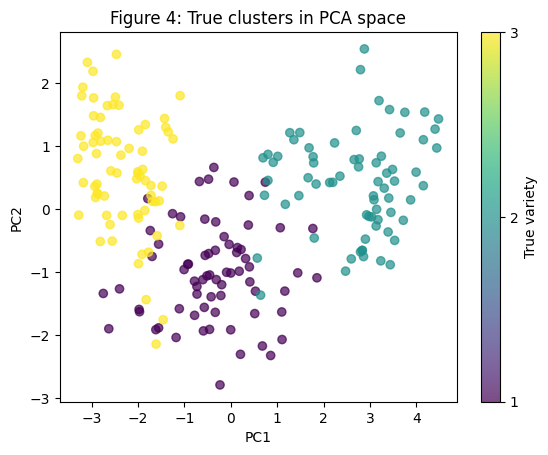

In [9]:
plt.scatter(X2[:, 0], X2[:, 1], c=y_true, cmap="viridis", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
cbar = plt.colorbar(label="True variety")
cbar.set_ticks([1, 2, 3])
plt.title("Figure 4: True clusters in PCA space")
plt.savefig("true_labels_pca.png", dpi=150, bbox_inches="tight")
plt.show()

### Observations on the PCA plot

This scatter plot reveals the ground truth of the dataset, where each seed is colored by its true variety. We notice that there is even more overlap between the real categories than the ones predicted by our K-Means model, which explains the minor misclassifications in our purity analysis. Despite this, the overall structures of the true groups closely resemble our unsupervised clustering results.

### What each cluster captured



In [10]:
cluster_centers = scaler.inverse_transform(km.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=feature_names)
print(cluster_centers_df)

        area  perimeter  compactness  kernel_length  kernel_width  asymmetry  \
0  11.856944  13.247778     0.848253       5.231750      2.849542   4.742389   
1  18.495373  16.203433     0.884210       6.175687      3.697537   3.632373   
2  14.437887  14.337746     0.881597       5.514577      3.259225   2.707341   

   groove_length  
0       5.101722  
1       6.041701  
2       5.120803  


### Ethical considerations

While clustering is a powerful analytical tool, it generates mathematical interpretations rather than absolute ground truths. If the cooperative relies solely on these unsupervised results to make operational decisions, several key risks emerge:

1. **Misclassification and Quality Degradation:** The purity score indicates that approximately 8% of the seeds are misclassified, with the errors concentrated in Variety 1. Mixing distinct varieties during automated sorting could lead to cross-contamination, ultimately degrading the quality of the final product and impacting market trust.
2. **Arbitrary Categorization and Model Selection Risks:** Determining the "correct" number of varieties is not always straightforward. In this analysis, while we selected $k=3$ based on the elbow method and PCA diagram, the silhouette score statistically favored $k=2$. In more complex datasets, blind reliance on automated metrics without domain expertise could easily lead to an incorrect division of products.

Ultimately, this unsupervised pipeline serves as an excellent exploratory guide, but empirical validation and real-world quality control remain essential to prevent costly operational errors.

### Project Reflection

Based on our diagnostic analysis, the Elbow method supported $k=3$ due to a sharp drop in inertia, whereas the Silhouette score peaked at $k=2$ ($\approx 0.47$) before dropping to a still-robust $\approx 0.40$ for $k=3$. We resolved this disagreement by choosing $k=3$, which captures the distinct sub-structures within the data.

According to the cross-tabulation and the high overall purity score of $\approx 91.9\%$, the K-Means clustering successfully recovered a significant portion of the true variety structure.

Variety 2 was separated most cleanly (capturing 65 out of 70 samples in Cluster 1), while Variety 1 proved the hardest to isolate, showing noticeable overlap with both other groups in Cluster 2. This continuous transition and overlap are clearly reflected in the colored PCA scatter plot, where the boundaries between the classes appear fuzzy.

Finally, we must remain cautious when evaluating this clustering on a 2D PCA plot; although it visualizes $\approx 89\%$ of the dataset's variance, compressing seven geometric features into two dimensions inherently discards finer multidimensional details that might prevent a more complete separation of the groups.